In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


## 데이터 기본 정보 확인

In [4]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print("=== 데이터 크기 ===")
print(f"Train data shape: {train.shape}")
print(f"Test data shape: {test.shape}\n")

print("=== 훈련 데이터 정보 ===")
train.info()

=== 데이터 크기 ===
Train data shape: (1460, 81)
Test data shape: (1459, 80)

=== 훈련 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  House

## 타깃값 분포 시각화(히스토그램)

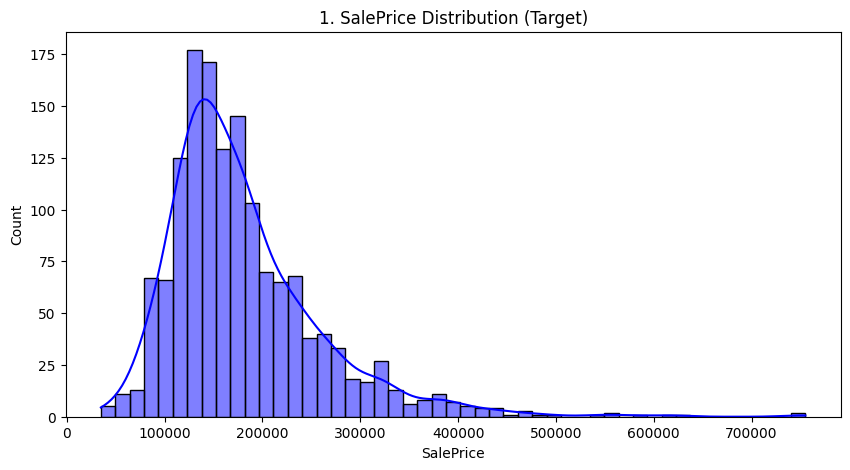

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(train['SalePrice'], kde=True, color='blue')
plt.title('1. SalePrice Distribution (Target)')
plt.show()

## 주요 피처와 타깃의 관계 

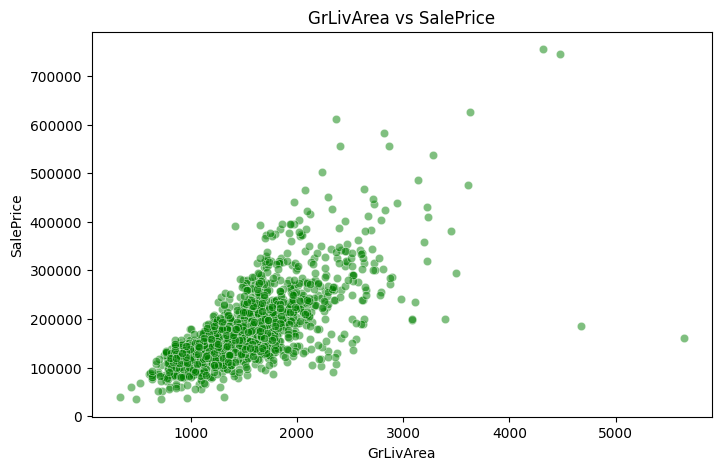

In [14]:
numeric_train = train.select_dtypes(include=['int64', 'float64'])
corrmat = numeric_train.corr()

top_corr_cols = corrmat.nlargest(10, 'SalePrice')['SalePrice'].index

plt.figure(figsize=(8, 5))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], color='green', alpha=0.5)
plt.title('GrLivArea vs SalePrice')
plt.show()

## 결측값 현황(막대그래프)

=== 주요 결측값 현황 테이블 ===


,Missing_Count,Missing_Ratio(%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


/tmp/ipykernel_55/1147359292.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.index[:10], y=missing.values[:10], palette='magma')


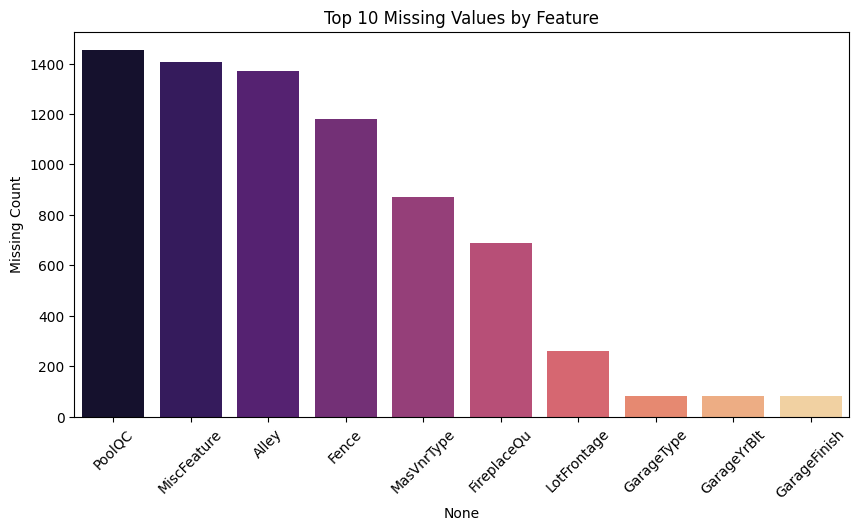

In [13]:
import pandas as pd

# 결측값 계산
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

# 3-1. 결측값 테이블 출력 (비율 포함)
missing_df = pd.DataFrame({
    'Missing_Count': missing, 
    'Missing_Ratio(%)': (missing / len(train)) * 100
})
print("=== 주요 결측값 현황 테이블 ===")
display(missing_df.head(10))

# 3-2. 결측값 막대 그래프
plt.figure(figsize=(10, 5))
sns.barplot(x=missing.index[:10], y=missing.values[:10], palette='magma')
plt.xticks(rotation=45)
plt.title('Top 10 Missing Values by Feature')
plt.ylabel('Missing Count')
plt.show()

## 훈련 모델 성능 평가

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

y = np.log1p(train['SalePrice'])
X = train.drop(['Id', 'SalePrice'], axis=1)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

num_transformer = SimpleImputer(strategy='median')
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Validation R² Score: {val_r2:.4f}")

Train RMSE: 0.0534
Validation RMSE: 0.1458
Train R² Score: 0.9813
Validation R² Score: 0.8861


## 성능 개선(모델 변경 XGBoost)

In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
import xgboost as xgb

model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', xgb.XGBRegressor(
        n_estimators=500,        
        learning_rate=0.05,    
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])

model_xgb.fit(X_train, y_train)

val_pred_xgb = model_xgb.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, val_pred_xgb))

print(f"기존 베이스라인(Random Forest) RMSE: {val_rmse:.4f}")
print(f"개선된 모델(XGBoost) RMSE: {xgb_rmse:.4f}")

기존 베이스라인(Random Forest) RMSE: 0.1458
개선된 모델(XGBoost) RMSE: 0.1425


In [20]:
test_ids = test['Id']
X_test = test.drop(['Id'], axis=1)

test_predictions = np.expm1(model_xgb.predict(X_test))

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions
})

submission.to_csv('submission.csv', index=False)

✅ 제출용 파일(submission.csv)이 성공적으로 저장되었습니다!
